# Домашнее задание. Визуализация данных с Matplotlib

Работаем с файлом:

```text
new_laptop.csv
```

который был подготовлен на занятии.

## Общие требования

Во всех заданиях используйте Pandas для подготовки данных и Matplotlib или Seaborn для визуализации.

Для графиков:

- добавляйте понятный заголовок;
- подписывайте оси, где это применимо;
- добавляйте легенду, если на одном графике несколько наборов данных;
- используйте сетку там, где она помогает читать график.

Задания выполняются последовательно. Если в предыдущей задаче был создан 
новый столбец, можно использовать его дальше, не создавая повторно. (при 
реализации в юпитер ноутбук)

Все выводы данных - примерные и могут отличаться.

---

# Задание 1. Распределение диагоналей

Постройте гистограмму распределения диагоналей ноутбуков.

Используйте `10` интервалов.

По горизонтальной оси должна быть диагональ экрана, по вертикальной - 
количество ноутбуков.

### Контроль

В датасете:

```text
Количество ноутбуков: 1302
Минимальная диагональ: 10.1
Максимальная диагональ: 18.4
```

---

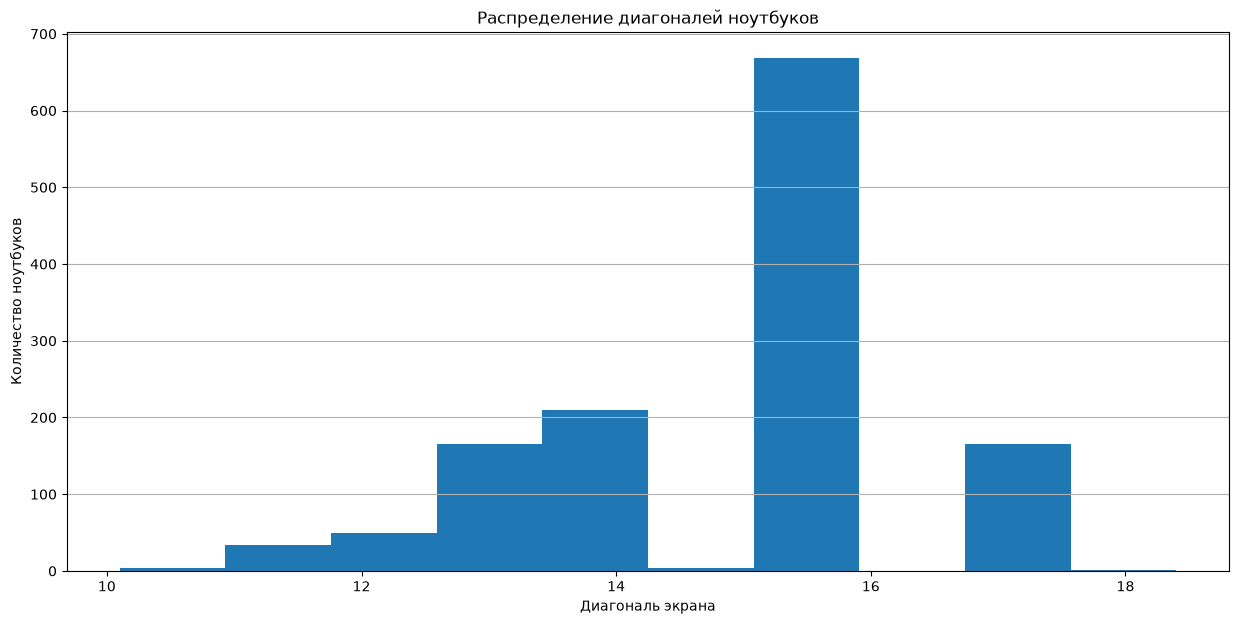

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r'C:\NextCloud\py\test_py\hw\hw14\new_laptop.csv', encoding='utf-8')

fig, ax = plt.subplots(figsize=(15, 7))
ax.hist(df["Inches"], bins=10)
ax.set_title("Распределение диагоналей ноутбуков")
ax.set_xlabel("Диагональ экрана")
ax.set_ylabel("Количество ноутбуков")
ax.grid(True, axis="y")
plt.show()


# Задание 2. Цена разных типов ноутбуков

Для каждого типа ноутбука определите медианную цену.

Отсортируйте результат по возрастанию цены и постройте столбчатую диаграмму.

### Контрольные данные

```text
Netbook               340.0
Notebook              691.0
2 in 1 Convertible   1199.0
Gaming               1492.8
Ultrabook            1499.0
Workstation          2064.9
```



In [8]:
print(df.groupby('TypeName')['Price_euros'].median().sort_values().to_frame().reset_index())


             TypeName  Price_euros
0             Netbook        340.0
1            Notebook        691.0
2  2 in 1 Convertible       1199.0
3              Gaming       1492.8
4           Ultrabook       1499.0
5         Workstation       2064.9


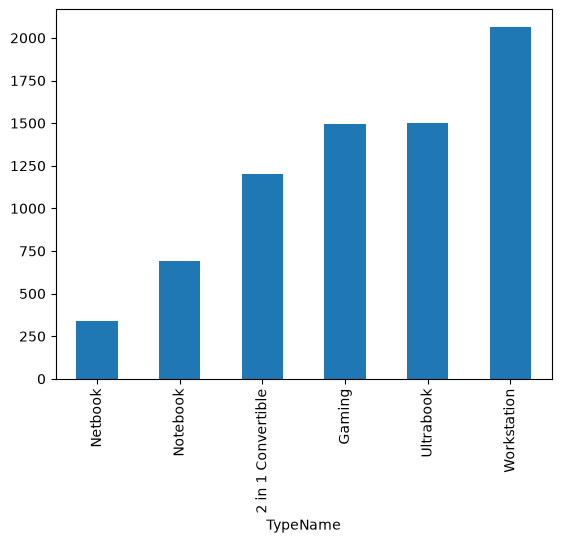

In [9]:
df.groupby('TypeName')['Price_euros'].median().sort_values().plot.bar()
plt.show()


# Задание 3. Типы накопителей

Создайте столбец:

```text
Storage_type
```

Категории:

```text
есть SSD и HDD -> SSD + HDD
есть SSD       -> SSD
есть HDD       -> HDD
остальные      -> Другое
```

После этого постройте круговую диаграмму распределения ноутбуков по типу накопителя.

На диаграмме должны отображаться проценты.

### Контрольные данные

```text
SSD          642
HDD          376
SSD + HDD    200
Другое        84
```


In [ ]:


df['Storage_type'] = df['Memory'].apply(lambda x: 'SSD + HDD' if 'SSD' in x and 'HDD' in x else 'SSD' if 'SSD' in x else 'HDD' if 'HDD' in x else 'Другое')

df['Storage_type'].value_counts()


Storage_type
SSD          642
HDD          376
SSD + HDD    200
Другое        84
Name: count, dtype: int64

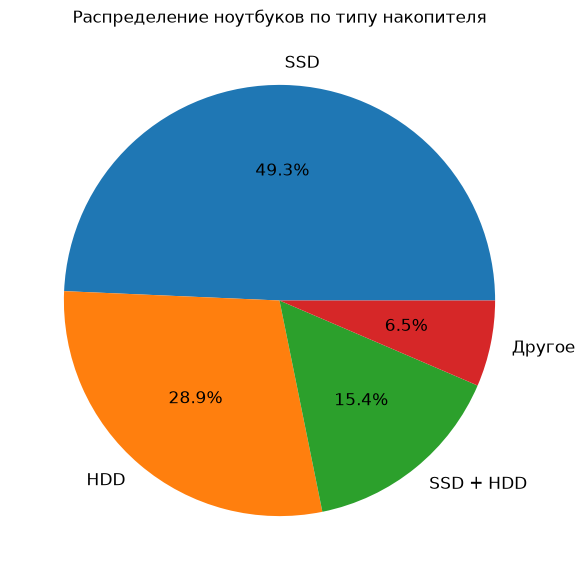

In [13]:
df['Storage_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(10, 7), fontsize=12, title='Распределение ноутбуков по типу накопителя')

plt.show()


# Задание 4. Диагональ и цена

Сравните ноутбуки с:

```text
Windows 10
```

и:

```text
macOS
```

Постройте диаграмму рассеяния:

- по X — диагональ;
- по Y — цена;
- обе операционные системы должны быть показаны на одном графике.

Добавьте легенду.

### Контроль

```text
Windows 10: 1072 модели
macOS:        12 моделей
```

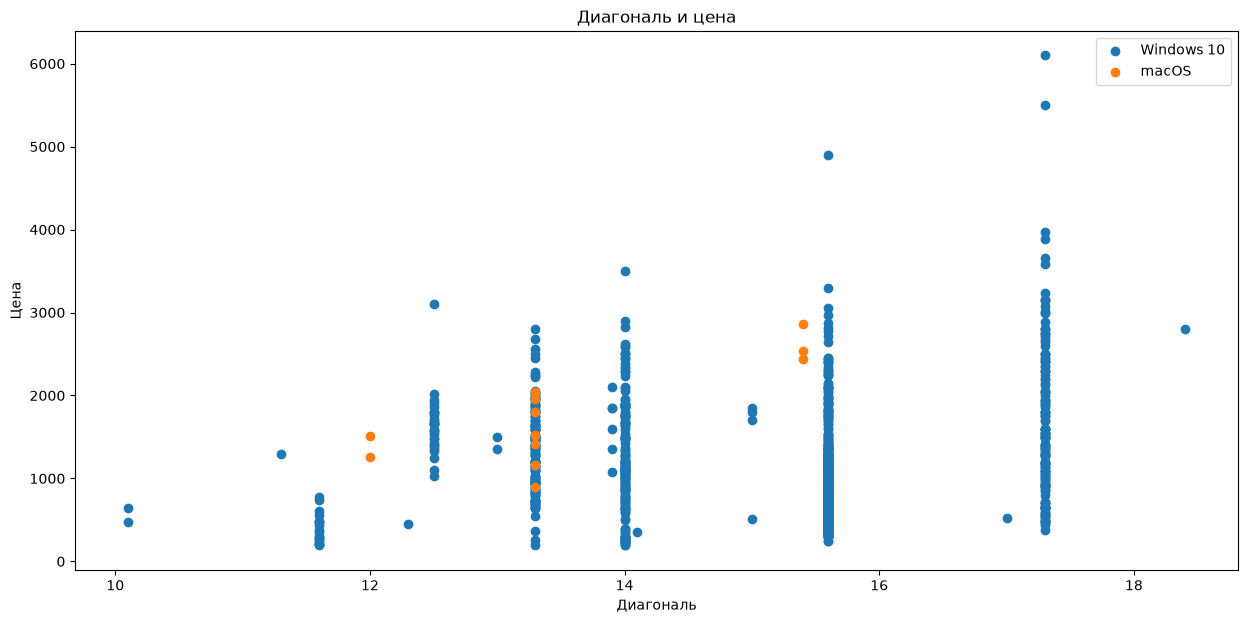

In [14]:
mask1 = df["OpSys"] == "Windows 10"
mask2 = df["OpSys"] == "macOS"
hw1 = df[mask1]
hw2 = df[mask2]

fig, ax = plt.subplots(figsize=(15, 7))
ax.scatter(hw1["Inches"], hw1["Price_euros"], label='Windows 10')
ax.scatter(hw2["Inches"], hw2["Price_euros"], label='macOS')
ax.set_title("Диагональ и цена")
ax.set_xlabel("Диагональ")
ax.set_ylabel("Цена")
ax.legend()
plt.show()


# Задание 5. Типы экранов

Создайте столбец:

```text
Display_type
```

Правила:

```text
IPS Panel + Touchscreen -> IPS Touch
только Touchscreen      -> Touch
только IPS Panel        -> IPS
остальные               -> Обычный
```

Оставьте модели стоимостью не более:

```text
1500 евро
```

С помощью Seaborn постройте диаграмму количества ноутбуков каждого типа экрана.

### Контрольные данные

```text
Обычный      709
IPS          183
IPS Touch     53
Touch         53
```


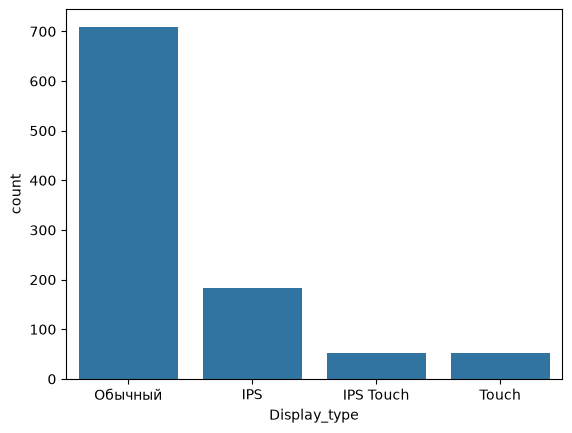

In [17]:
import seaborn as sns

df = pd.read_csv(r'C:\NextCloud\py\test_py\hw\hw14\new_laptop.csv', encoding='utf-8')

df['Display_type'] = df['ScreenResolution'].apply(lambda x: 'IPS Touch' if x.find('IPS Panel') != -1 and x.find('Touchscreen') != -1 else 'Touch' if x.find('Touchscreen') != -1 else 'IPS' if x.find('IPS Panel') != -1 else 'Обычный')

df = df[df['Price_euros'] <= 1500]

sns.countplot(x='Display_type', data=df)
plt.show()



# Задания со звёздочкой ⭐

## Задание 6 ⭐. Сравнение распределения цен

Сравните распределение цен:

```text
Gaming
Ultrabook
```

на **одной гистограмме**.

Границы интервалов сформируйте средствами NumPy:

```text
от 0 до 6500 евро
шаг 500 евро
```

Гистограммы должны быть полупрозрачными, чтобы было видно их пересечение.

Добавьте легенду.

### Контроль

```text
Gaming:    205 моделей
Ultrabook: 195 моделей

Медианная цена Gaming:    1492.8
Медианная цена Ultrabook: 1499.0
```


In [ ]:

gaming = df[df.TypeName == 'Gaming']
ultrabook = df[df.TypeName == 'Ultrabook']

gaming['Price_euros'].plot(kind='hist', bins=np.arange(0, 6500, 500), alpha=0.5, label='Gaming')
ultrabook['Price_euros'].plot(kind='hist', bins=np.arange(0, 6500, 500), alpha=0.5, label='Ultrabook')
plt.legend()

print(f'Gaming:    {gaming.shape[0]} моделей')
print(f'Ultrabook: {ultrabook.shape[0]} моделей')

print(f'Медианная цена Gaming:    {gaming.Price_euros.median()}')
print(f'Медианная цена Ultrabook: {ultrabook.Price_euros.median()}')

plt.show()



## Задание 7 ⭐. HP против Lenovo

Для компаний:

```text
HP
Lenovo
```

определите медианную цену для каждой диагонали экрана.

Для графика оставьте только диагонали, которые встречаются у конкретного производителя не менее `5` раз.

Постройте на одном графике две линии:

- HP;
- Lenovo.

Добавьте маркеры точек и легенду.

### Контроль

Для HP должны остаться:

```text
11.6 -> 385.00
12.5 -> 1569.00
13.3 -> 1349.00
14.0 -> 1099.99
15.6 -> 684.90
17.3 -> 1080.00
```

Для Lenovo:

```text
12.5 -> 1650.0
13.3 -> 1399.0
13.9 -> 1724.0
14.0 -> 1354.5
15.6 -> 779.0
17.3 -> 698.0
```


In [29]:
mask1 = df["Company"] == "HP"
mask2 = df["Company"] == "Lenovo"

df1 = df[mask1]
df2 = df[mask2]
df1 = df1[df1["Inches"].isin(df1["Inches"].value_counts()[df1["Inches"].value_counts() >= 5].index)]
df2 = df2[df2["Inches"].isin(df2["Inches"].value_counts()[df2["Inches"].value_counts() >= 5].index)]

df1["Inches"].value_counts()


Inches
15.6    118
14.0     37
17.3     26
13.3     24
11.6      7
12.5      6
Name: count, dtype: int64

In [30]:
df2["Inches"].value_counts()

Inches
15.6    141
14.0     44
13.3     17
17.3     15
Name: count, dtype: int64

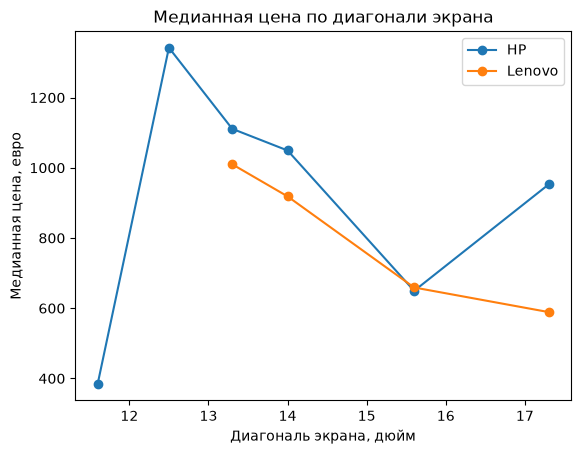

In [31]:

df1 = df1.groupby("Inches").agg({"Price_euros": "median"}).reset_index()
df2 = df2.groupby("Inches").agg({"Price_euros": "median"}).reset_index()


plt.plot(df1["Inches"], df1["Price_euros"], marker="o", label="HP")
plt.plot(df2["Inches"], df2["Price_euros"], marker="o", label="Lenovo")
plt.xlabel("Диагональ экрана, дюйм")
plt.ylabel("Медианная цена, евро")
plt.title("Медианная цена по диагонали экрана")
plt.legend()
plt.show()



---

## Задание 8 ⭐. Медианная цена производителей

Для каждого производителя определите:

- количество моделей;
- медианную цену.

Оставьте только компании, у которых в датасете не менее `20` ноутбуков.

Отсортируйте их по медианной цене от большей к меньшей и постройте столбчатую диаграмму.

### Контрольные данные

```text
Company   Count   Median

MSI          54   1599.0
Apple        20   1359.5
Toshiba      48   1211.5
Asus        158   1012.5
Dell        297    985.0
HP          274    966.5
Lenovo      297    899.0
Acer        103    559.0
```


         count  median
Company               
MSI         23  1199.0
Toshiba     35  1095.0
Dell       228   857.0
HP         219   764.0
Asus       120   759.0
Lenovo     231   739.0
Acer       100   546.5


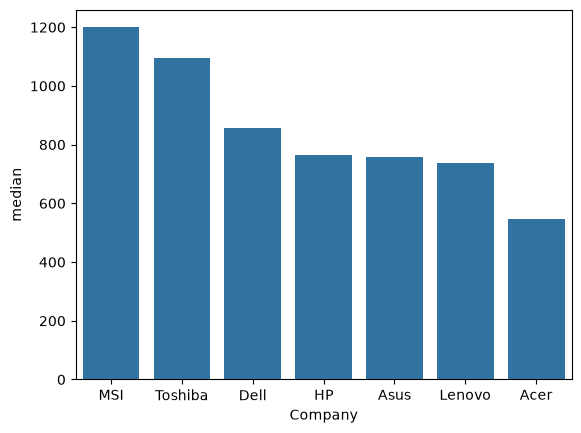

In [32]:
df1 = df[['Company', 'Price_euros']]
df1 = df1[df1["Company"].isin(df1["Company"].value_counts()[df1["Company"].value_counts() >= 20].index)]
df1 = df1.groupby(['Company'])['Price_euros'].agg(['count', 'median']).sort_values(['median'], ascending=False)

print(df1)

sns.barplot(data=df1, x='Company', y='median')

plt.show()




## Задание 9 ⭐. Накопители премиальных лёгких ноутбуков

Используйте `Storage_type` из задания 3.

Оставьте ноутбуки:

```text
Price_euros >= 1500
Weight_kg <= 2.5
```

С помощью Seaborn постройте диаграмму количества моделей для каждого типа накопителя.

### Контроль

Всего должно остаться:

```text
211 ноутбуков
```

По типам накопителей:

```text
SSD          181
SSD + HDD     23
HDD            4
Другое         3
```


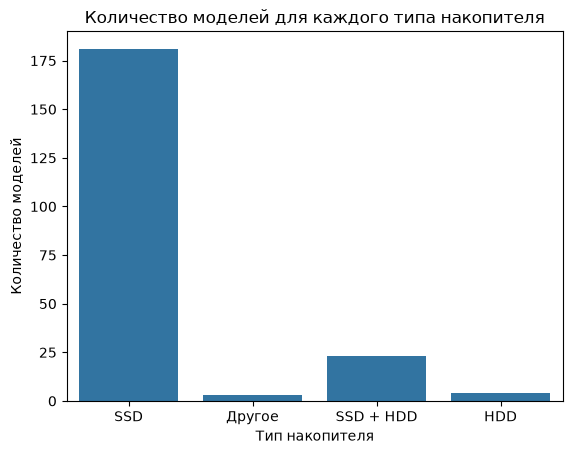

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r'C:\NextCloud\py\test_py\hw\hw14\new_laptop.csv', encoding='utf-8')

df['Storage_type'] = df['Memory'].apply(lambda x: 'SSD + HDD' if 'SSD' in x and 'HDD' in x else 'SSD' if 'SSD' in x else 'HDD' if 'HDD' in x else 'Другое')

mask1 = df['Price_euros'] >= 1500
mask2 = df['Weight_kg'] <= 2.5
#mask3 = df['Storage_type'] != 'Другое'

df = df[mask1 & mask2 ] # & mask3]

sns.countplot(x='Storage_type', data=df)
plt.title('Количество моделей для каждого типа накопителя')
plt.xlabel('Тип накопителя')
plt.ylabel('Количество моделей')
plt.show()




## Задание 10 ⭐. Аналитический отчёт

Используйте столбцы:

```text
Storage_type
Display_type
```

из предыдущих заданий.

Сформируйте выборку:

```text
OpSys = Windows 10
Weight_kg <= 2.5
Price_euros <= 2000
```


По этим данным постройте **три разных графика**.

### График 1

Определите медианную цену для каждого типа ноутбука.

Для графика оставьте только типы, представленные не менее чем `10` моделями.

Постройте столбчатую диаграмму.

Контроль:

```text
Netbook               15    475.00
Notebook             526    720.32
2 in 1 Convertible    94   1164.00
Gaming                50   1190.40
Ultrabook            130   1463.00
```

---

                    Price_euros
TypeName                       
2 in 1 Convertible      1164.00
Gaming                  1190.40
Netbook                  475.00
Notebook                 720.32
Ultrabook               1463.00


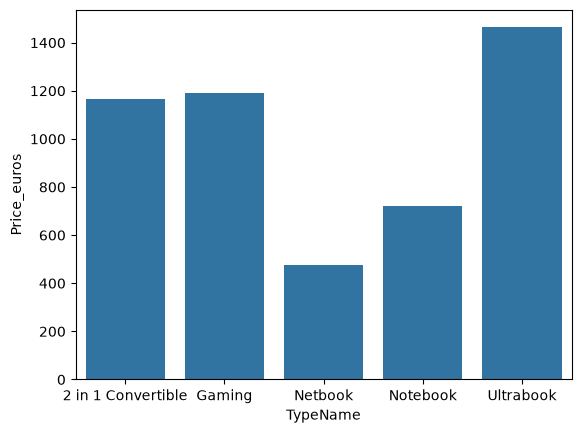

In [40]:
df = pd.read_csv(r'C:\NextCloud\py\test_py\hw\hw14\new_laptop.csv', encoding='utf-8')

df['Storage_type'] = df['Memory'].apply(lambda x: 'SSD + HDD' if 'SSD' in x and 'HDD' in x else 'SSD' if 'SSD' in x else 'HDD' if 'HDD' in x else 'Другое')

df['Display_type'] = df['ScreenResolution'].apply(lambda x: 'IPS Touch' if x.find('IPS Panel') != -1 and x.find('Touchscreen') != -1 else 'Touch' if x.find('Touchscreen') != -1 else 'IPS' if x.find('IPS Panel') != -1 else 'Обычный')

df = df[(df['OpSys'] == 'Windows 10') & (df['Weight_kg'] <= 2.5) & (df['Price_euros'] <= 2000)]

df1 = df.copy()

df1 = df1[df1['TypeName'].isin(df1['TypeName'].value_counts()[df1['TypeName'].value_counts() >= 10].index)] 

df1 = df1.groupby('TypeName').agg({'Price_euros': 'median'})

print(df1)

sns.barplot(x=df1.index, y=df1['Price_euros'])

plt.show()


### График 2

Постройте круговую диаграмму типов накопителей.

Контроль:

```text
SSD          461
HDD          243
SSD + HDD     72
Другое        45
```


Storage_type
SSD          461
HDD          243
SSD + HDD     72
Другое        45
Name: count, dtype: int64


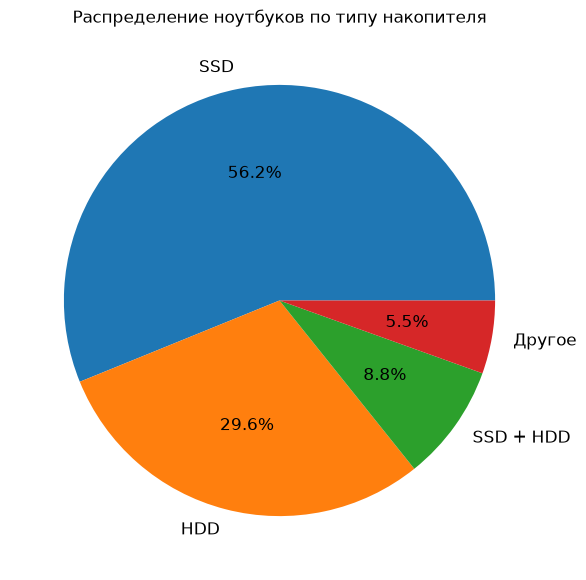

In [41]:
print(df['Storage_type'].value_counts())

df['Storage_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(10, 7), fontsize=12, title='Распределение ноутбуков по типу накопителя')

plt.show()


### График 3

Сравните:

```text
IPS
IPS Touch
```

на диаграмме рассеяния:

- X — диагональ;
- Y — цена.

Оба типа должны находиться на одном графике.

Контроль:

```text
IPS:       155 моделей
IPS Touch:  66 моделей
```
---

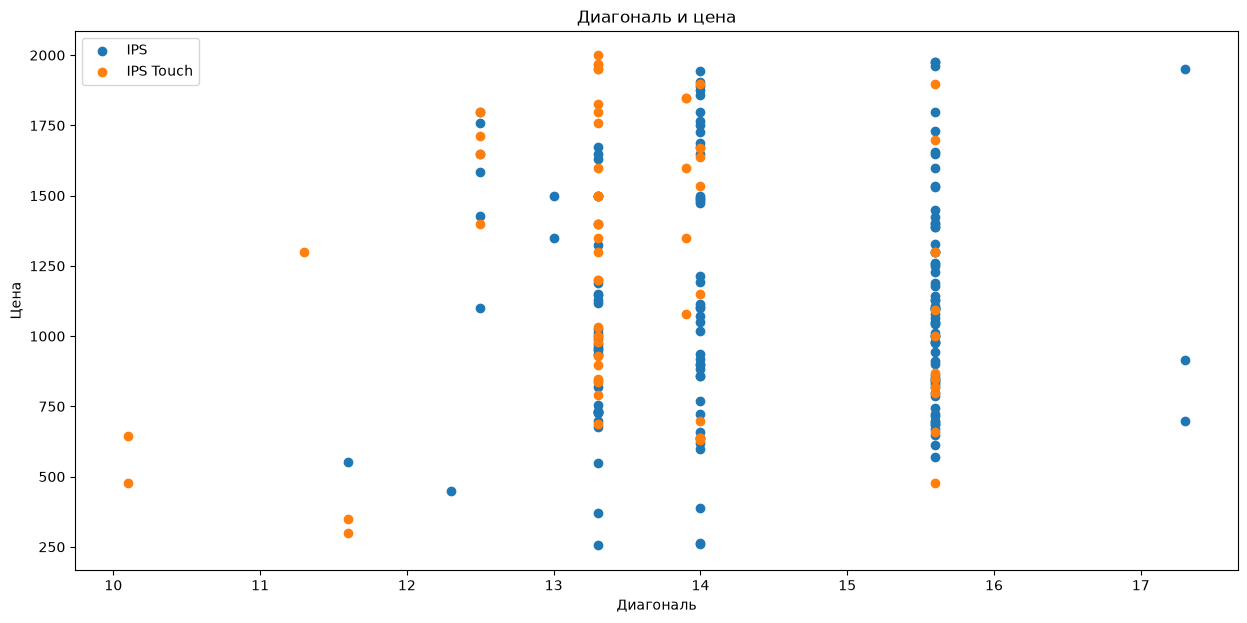

In [42]:
df1 = df.copy()

mask1 = df1["Display_type"] == "IPS"
mask2 = df1["Display_type"] == "IPS Touch"
hw1 = df1[mask1]
hw2 = df1[mask2]

fig, ax = plt.subplots(figsize=(15, 7))



ax.scatter(hw1["Inches"], hw1["Price_euros"], label='IPS')
ax.scatter(hw2["Inches"], hw2["Price_euros"], label='IPS Touch')
ax.set_title("Диагональ и цена")
ax.set_xlabel("Диагональ")
ax.set_ylabel("Цена")
ax.legend()
plt.show()